In [1]:
import os
import torch
import torch.nn as nn
import pandas as pd
import pickle
import random
import matplotlib.pyplot as plt
import torchvision.models as models
import torchvision.transforms as T
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence
from torchvision.models import MobileNet_V2_Weights
import spacy

spacy_eng = spacy.load("en_core_web_sm")
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
print(f"GPU count: {torch.cuda.device_count()}")

Using device: cuda
GPU count: 2


In [2]:
class Vocabulary:
    def __init__(self, freq_threshold):
        self.freq_threshold = freq_threshold
        self.itos = {0: "<PAD>", 1: "<SOS>", 2: "<EOS>", 3: "<UNK>"}
        self.stoi = {v: k for k, v in self.itos.items()}

    def __len__(self):
        return len(self.itos)

    @staticmethod
    def tokenize(text):
        return [token.text.lower() for token in spacy_eng.tokenizer(text)]

    def build_vocab(self, sent_list):
        freqs = {}
        idx = 4
        for sent in sent_list:
            sent = str(sent)
            for word in self.tokenize(sent):
                if word not in freqs:
                    freqs[word] = 1
                else:
                    freqs[word] += 1
                if freqs[word] == self.freq_threshold:
                    self.itos[idx] = word
                    self.stoi[word] = idx
                    idx += 1

    def numericalize(self, sents):
        tokens = self.tokenize(sents)
        return [self.stoi[token] if token in self.stoi else self.stoi["<UNK>"]
                for token in tokens]

In [3]:
class FlickrDataset(Dataset):
    def __init__(self, root_dir, caps, transforms=None, freq_threshold=5):
        self.root_dir = root_dir
        self.df = pd.read_csv(caps, delimiter='|')
        self.transforms = transforms

        self.df = self.df.dropna(subset=[' comment'])
        self.df = self.df.reset_index(drop=True)

        self.img_pts = self.df['image_name']
        self.caps    = self.df[' comment']

        self.vocab = Vocabulary(freq_threshold)
        self.vocab.build_vocab(self.caps.tolist())

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        caption = str(self.caps[idx])
        img_pt  = self.img_pts[idx]
        img     = Image.open(os.path.join(self.root_dir, img_pt)).convert('RGB')
        if self.transforms is not None:
            img = self.transforms(img)
        tokens  = [self.vocab.stoi["<SOS>"]]
        tokens += self.vocab.numericalize(caption)
        tokens += [self.vocab.stoi["<EOS>"]]
        return img, torch.tensor(tokens), img_pt

In [4]:
class CapCollat:
    def __init__(self, pad_seq, batch_first=False):
        self.pad_seq     = pad_seq
        self.batch_first = batch_first

    def __call__(self, batch):
        imgs        = [itm[0].unsqueeze(0) for itm in batch]
        imgs        = torch.cat(imgs, dim=0)
        target_caps = [itm[1] for itm in batch]
        target_caps = pad_sequence(target_caps, batch_first=self.batch_first,
                                   padding_value=self.pad_seq)
        img_names   = [itm[2] for itm in batch]
        return imgs, target_caps, img_names

In [5]:
ROOT_DIR  = '/kaggle/input/datasets/hsankesara/flickr-image-dataset/flickr30k_images/flickr30k_images'
CAPS_FILE = '/kaggle/input/datasets/hsankesara/flickr-image-dataset/flickr30k_images/results.csv'

weights   = MobileNet_V2_Weights.DEFAULT
transform = weights.transforms()

dataset = FlickrDataset(
    root_dir=ROOT_DIR,
    caps=CAPS_FILE,
    transforms=transform
)

dataloader = DataLoader(
    dataset,
    batch_size=32,
    shuffle=True,
    collate_fn=CapCollat(pad_seq=dataset.vocab.stoi['<PAD>'])
)

print(f"Dataset size: {len(dataset)}")
print(f"Vocab size:   {len(dataset.vocab)}")

Dataset size: 158914
Vocab size:   7666


In [6]:
FEATURES_FILE = 'flickr30k_features_MNV2.pkl'
print("--------------- Feature Extraction--------------------------------------------------")
if os.path.exists(FEATURES_FILE):
    print("Loading features from pickle...")
    with open(FEATURES_FILE, 'rb') as f:
        image_features = pickle.load(f)
    print(f"Loaded features for {len(image_features)} images")

else:
    print("Extracting features with MobileNetV2...")
    mobilenet            = models.mobilenet_v2(weights=MobileNet_V2_Weights.DEFAULT)
    mobilenet.classifier = nn.Identity()   # removes classifier, keeps 1280-d output
    mobilenet            = mobilenet.to(device)
    mobilenet.eval()

    image_features = {}
    with torch.no_grad():
        for batch_idx, (images, captions, img_names) in enumerate(dataloader):
            images = images.to(device)
            feats  = mobilenet(images)
            feats  = feats.view(feats.size(0), -1)   # (batch, 1280)
            for i, img_name in enumerate(img_names):
                image_features[img_name] = feats[i].cpu().numpy()
            if batch_idx % 100 == 0:
                print(f"  Processed {batch_idx * 32} / {len(dataset)} images...")

    with open(FEATURES_FILE, 'wb') as f:
        pickle.dump(image_features, f)
    print(f"Done. Extracted features for {len(image_features)} images")

sample_key = list(image_features.keys())[0]
print(f"Sample: {sample_key} -> shape {image_features[sample_key].shape}")

--------------- Feature Extraction--------------------------------------------------
Extracting features with MobileNetV2...
Downloading: "https://download.pytorch.org/models/mobilenet_v2-7ebf99e0.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-7ebf99e0.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 164MB/s]


  Processed 0 / 158914 images...
  Processed 3200 / 158914 images...
  Processed 6400 / 158914 images...
  Processed 9600 / 158914 images...
  Processed 12800 / 158914 images...
  Processed 16000 / 158914 images...
  Processed 19200 / 158914 images...
  Processed 22400 / 158914 images...
  Processed 25600 / 158914 images...
  Processed 28800 / 158914 images...
  Processed 32000 / 158914 images...
  Processed 35200 / 158914 images...
  Processed 38400 / 158914 images...
  Processed 41600 / 158914 images...
  Processed 44800 / 158914 images...
  Processed 48000 / 158914 images...
  Processed 51200 / 158914 images...
  Processed 54400 / 158914 images...
  Processed 57600 / 158914 images...
  Processed 60800 / 158914 images...
  Processed 64000 / 158914 images...
  Processed 67200 / 158914 images...
  Processed 70400 / 158914 images...
  Processed 73600 / 158914 images...
  Processed 76800 / 158914 images...
  Processed 80000 / 158914 images...
  Processed 83200 / 158914 images...
  Proces

In [7]:
print("--------------- Encoder-------------------------------------------------------------")
class Encoder(nn.Module):
    def __init__(self, feature_size, hidden_size):
        super().__init__()
        self.fc1     = nn.Linear(feature_size, hidden_size)
        self.ln1     = nn.LayerNorm(hidden_size)
        self.relu    = nn.ReLU()
        self.dropout = nn.Dropout(0.3)

    def forward(self, x):
        h = self.dropout(self.relu(self.ln1(self.fc1(x))))
        c = self.dropout(self.relu(self.ln1(self.fc1(x))))
        return h.unsqueeze(0), c.unsqueeze(0)


class Decoder(nn.Module):
    print("--------------- Decoder----------------------------------------------------------")
    def __init__(self, vocab_size, embed_size, hidden_size):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_size)
        self.embed_ln  = nn.LayerNorm(embed_size)
        self.lstm      = nn.LSTM(embed_size, hidden_size, batch_first=True)
        self.dropout   = nn.Dropout(0.3)
        self.fc        = nn.Linear(hidden_size, vocab_size)

    def forward(self, captions, hidden, cell):
        embeddings          = self.embed_ln(self.embedding(captions))
        out, (hidden, cell) = self.lstm(embeddings, (hidden, cell))
        output              = self.fc(self.dropout(out))
        return output, hidden, cell


class Seq2Seq(nn.Module):
    def __init__(self, vocab_size, embed_size, hidden_size, feature_size=1280):
        super().__init__()
        self.encoder = Encoder(feature_size, hidden_size)
        self.decoder = Decoder(vocab_size, embed_size, hidden_size)

    def forward(self, features, captions):
        hidden, cell    = self.encoder(features)
        outputs, _, _   = self.decoder(captions, hidden, cell)
        return outputs

print("Model classes defined.")

--------------- Encoder-------------------------------------------------------------
--------------- Decoder----------------------------------------------------------
Model classes defined.


In [8]:
class FeatureDataset(Dataset):
    def __init__(self, features_dict, df, vocab):
        self.features_dict = features_dict
        self.vocab         = vocab
        self.samples       = []
        for _, row in df.iterrows():
            img_name = row['image_name']
            caption  = str(row[' comment'])
            if img_name in features_dict:
                self.samples.append((img_name, caption))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_name, caption = self.samples[idx]
        features = torch.FloatTensor(self.features_dict[img_name])
        tokens   = [self.vocab.stoi['<SOS>']]
        tokens  += self.vocab.numericalize(caption)
        tokens  += [self.vocab.stoi['<EOS>']]
        return features, torch.LongTensor(tokens)

def feature_collate(batch):
    features, captions = zip(*batch)
    features = torch.stack(features, 0)
    captions = pad_sequence(captions, batch_first=True, padding_value=0)
    return features, captions

all_imgs = list(image_features.keys())
random.seed(42)
random.shuffle(all_imgs)

n          = len(all_imgs)
train_imgs = set(all_imgs[:int(0.8 * n)])
val_imgs   = set(all_imgs[int(0.8 * n):int(0.9 * n)])
test_imgs  = set(all_imgs[int(0.9 * n):])

train_df = dataset.df[dataset.df['image_name'].isin(train_imgs)].reset_index(drop=True)
val_df   = dataset.df[dataset.df['image_name'].isin(val_imgs)].reset_index(drop=True)
test_df  = dataset.df[dataset.df['image_name'].isin(test_imgs)].reset_index(drop=True)

train_dataset = FeatureDataset(image_features, train_df, dataset.vocab)
val_dataset   = FeatureDataset(image_features, val_df,   dataset.vocab)
test_dataset  = FeatureDataset(image_features, test_df,  dataset.vocab)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True,  collate_fn=feature_collate)
val_loader   = DataLoader(val_dataset,   batch_size=64, shuffle=False, collate_fn=feature_collate)

print(f"Train: {len(train_dataset)} | Val: {len(val_dataset)} | Test: {len(test_dataset)}")

Train: 127129 | Val: 15890 | Test: 15895


In [9]:
VOCAB_SIZE     = len(dataset.vocab)
EMBEDDING_SIZE = 512
HIDDEN_SIZE    = 512
FEATURE_SIZE   = 1280   # MobileNetV2 output size
NUM_EPOCHS     = 20
LR             = 0.001

model     = Seq2Seq(VOCAB_SIZE, EMBEDDING_SIZE, HIDDEN_SIZE, FEATURE_SIZE).to(device)
criterion = nn.CrossEntropyLoss(ignore_index=0)
optimizer = torch.optim.Adam(model.parameters(), lr=LR)

train_losses  = []
val_losses    = []
best_val_loss = float('inf')

for epoch in range(NUM_EPOCHS):
    model.train()
    total_loss = 0
    for features, captions in train_loader:
        features = features.to(device)
        captions = captions.to(device)
        inputs   = captions[:, :-1]
        targets  = captions[:, 1:]
        outputs  = model(features, inputs)
        loss     = criterion(outputs.reshape(-1, VOCAB_SIZE), targets.reshape(-1))
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    model.eval()
    val_loss = 0
    with torch.no_grad():
        for features, captions in val_loader:
            features = features.to(device)
            captions = captions.to(device)
            inputs   = captions[:, :-1]
            targets  = captions[:, 1:]
            outputs  = model(features, inputs)
            loss     = criterion(outputs.reshape(-1, VOCAB_SIZE), targets.reshape(-1))
            val_loss += loss.item()

    avg_train = total_loss / len(train_loader)
    avg_val   = val_loss   / len(val_loader)
    train_losses.append(avg_train)
    val_losses.append(avg_val)
    print(f"Epoch {epoch+1:02d}/{NUM_EPOCHS} | Train: {avg_train:.4f} | Val: {avg_val:.4f}")

    if avg_val < best_val_loss:
        best_val_loss = avg_val
        torch.save(model.state_dict(), 'best_model.pth')
        print(f"  Saved best model (val loss: {avg_val:.4f})")

Epoch 01/20 | Train: 3.2300 | Val: 2.8193
  Saved best model (val loss: 2.8193)
Epoch 02/20 | Train: 2.7350 | Val: 2.6745
  Saved best model (val loss: 2.6745)
Epoch 03/20 | Train: 2.5623 | Val: 2.6258
  Saved best model (val loss: 2.6258)
Epoch 04/20 | Train: 2.4478 | Val: 2.6071
  Saved best model (val loss: 2.6071)
Epoch 05/20 | Train: 2.3578 | Val: 2.6027
  Saved best model (val loss: 2.6027)
Epoch 06/20 | Train: 2.2841 | Val: 2.6072
Epoch 07/20 | Train: 2.2201 | Val: 2.6205
Epoch 08/20 | Train: 2.1636 | Val: 2.6346
Epoch 09/20 | Train: 2.1141 | Val: 2.6465
Epoch 10/20 | Train: 2.0698 | Val: 2.6622
Epoch 11/20 | Train: 2.0307 | Val: 2.6796
Epoch 12/20 | Train: 1.9951 | Val: 2.7040
Epoch 13/20 | Train: 1.9617 | Val: 2.7219
Epoch 14/20 | Train: 1.9324 | Val: 2.7388
Epoch 15/20 | Train: 1.9051 | Val: 2.7550
Epoch 16/20 | Train: 1.8810 | Val: 2.7757
Epoch 17/20 | Train: 1.8585 | Val: 2.7963
Epoch 18/20 | Train: 1.8371 | Val: 2.8137
Epoch 19/20 | Train: 1.8179 | Val: 2.8345
Epoch 20/20 

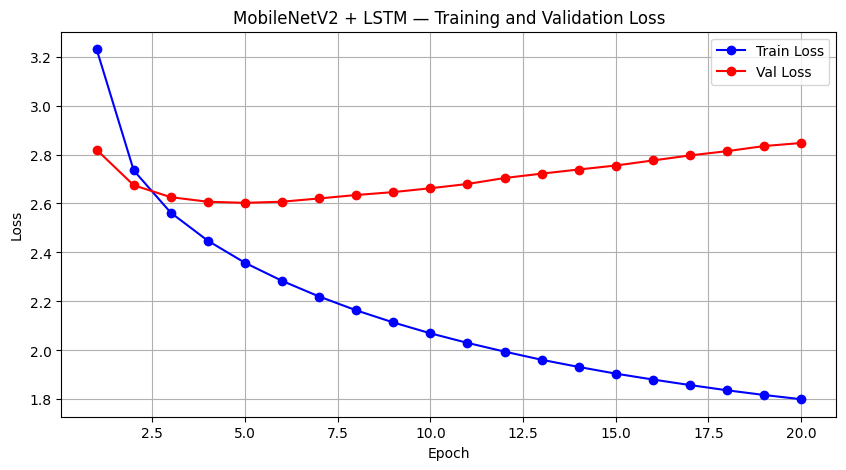

In [10]:
plt.figure(figsize=(10, 5))
plt.plot(range(1, len(train_losses)+1), train_losses, 'b-o', label='Train Loss')
plt.plot(range(1, len(val_losses)+1),   val_losses,   'r-o', label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('MobileNetV2 + LSTM — Training and Validation Loss')
plt.legend()
plt.grid(True)
plt.savefig('loss_curve.png')
plt.show()

In [11]:
def greedy_caption(model, image_feature, vocab, max_len=20):
    model.eval()
    idx2word = vocab.itos
    with torch.no_grad():
        feat          = torch.FloatTensor(image_feature).unsqueeze(0).to(device)
        hidden, cell  = model.encoder(feat)
        word          = torch.LongTensor([[vocab.stoi['<SOS>']]]).to(device)
        caption       = []
        for _ in range(max_len):
            out, hidden, cell = model.decoder(word, hidden, cell)
            word_id           = out.argmax(dim=2).item()
            if word_id == vocab.stoi['<EOS>']:
                break
            caption.append(idx2word[word_id])
            word = torch.LongTensor([[word_id]]).to(device)
    return ' '.join(caption)

model.load_state_dict(torch.load('best_model.pth'))
for img_name in list(test_imgs)[:5]:
    if img_name not in image_features:
        continue
    caption = greedy_caption(model, image_features[img_name], dataset.vocab)
    print(f"Image:   {img_name}")
    print(f"Caption: {caption}")
    print("-" * 50)

Image:   2095949968.jpg
Caption:   a young boy in a blue shirt is looking at a computer monitor .
--------------------------------------------------
Image:   3205754736.jpg
Caption:   a man in a red shirt and a woman in a red shirt are walking down the street .
--------------------------------------------------
Image:   2565237642.jpg
Caption:   a dog is running on the grass .
--------------------------------------------------
Image:   2663794355.jpg
Caption:   a man in a blue shirt and a woman in a blue shirt are sitting on a beach .
--------------------------------------------------
Image:   4934375269.jpg
Caption:   a group of people are sitting on a bench .
--------------------------------------------------


In [12]:
import nltk
from nltk.translate.bleu_score import corpus_bleu
from collections import Counter

nltk.download('punkt', quiet=True)

model.load_state_dict(torch.load('best_model.pth'))
model.eval()

references = []
hypotheses = []

print("Generating captions for test set...")
for img_name in list(test_imgs):
    if img_name not in image_features:
        continue
    generated = greedy_caption(model, image_features[img_name], dataset.vocab)
    hyp       = generated.split()
    gt_rows   = dataset.df[dataset.df['image_name'] == img_name][' comment']
    ref       = [str(cap).split() for cap in gt_rows.tolist()]
    references.append(ref)
    hypotheses.append(hyp)

bleu1 = corpus_bleu(references, hypotheses, weights=(1, 0, 0, 0))
bleu4 = corpus_bleu(references, hypotheses)

all_ref_tokens = []
all_hyp_tokens = []
for ref_list, hyp in zip(references, hypotheses):
    all_ref_tokens.extend(ref_list[0])
    all_hyp_tokens.extend(hyp)

ref_counter = Counter(all_ref_tokens)
hyp_counter = Counter(all_hyp_tokens)
tp          = sum((hyp_counter & ref_counter).values())
precision   = tp / sum(hyp_counter.values()) if hyp_counter else 0
recall      = tp / sum(ref_counter.values()) if ref_counter else 0
f1          = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

print(f"\n{'='*40}")
print(f"BLEU-1:    {bleu1:.4f}")
print(f"BLEU-4:    {bleu4:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")
print(f"{'='*40}")

Generating captions for test set...

BLEU-1:    0.5544
BLEU-4:    0.1306
Precision: 0.6665
Recall:    0.4640
F1-Score:  0.5471
